<a href="https://colab.research.google.com/github/fularisankade45-arch/Fulari-FML-practicals/blob/main/TASK_4_FULARI_ELECTRICAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


import matplotlib.pyplot as plt


**Step 1: Load Dataset**

In [ ]:
data = pd.read_csv("/content/wireless_signal_quality_dataset.xlsx - Sheet1.csv")

print("First Five Records")
data.head()

print("\nDataset Shape:")
print(data.shape)

First Five Records

Dataset Shape:
(100, 10)


**Step 2: Separate Features and Target**

In [ ]:
X = data.drop("Quality", axis=1)
y = data["Quality"]


**Step 3: Encode Target Labels**

In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("\nClasses:")
print(encoder.classes_)


Classes:
['Excellent' 'Fair' 'Good' 'Poor']


**Step 4: Split Dataset**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
     X,
     y,
     test_size=0.25,
     random_state=42,
     stratify=y
     )

**Step 5: Build Random Forest Model**

In [ ]:
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

**Step 6: Prediction**

In [ ]:
y_pred = dt.predict(X_test)

**Step 7: Accuracy**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy : {:.2f}%".format(accuracy * 100))


Accuracy : 92.00%


**Step 8: Classification Report**

In [ ]:
print("\nClassification Report:")

print(classification_report(
    y_test,
    y_pred,
    target_names=[str(c) for c in encoder.classes_]
    ))


Classification Report:
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00         1
        Fair       1.00      0.89      0.94         9
        Good       0.50      1.00      0.67         2
        Poor       1.00      1.00      1.00        13

    accuracy                           0.92        25
   macro avg       0.62      0.72      0.65        25
weighted avg       0.92      0.92      0.91        25



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Step 9: Confusion Matrix**

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 0  0  1  0]
 [ 0  8  1  0]
 [ 0  0  2  0]
 [ 0  0  0 13]]


**Step 10: Feature Importance**

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
    )

importance = importance.sort_values(ascending=False)

print("\nFeature Importance")

print(importance)


Feature Importance
Signal_Strength_dBm          0.363351
SNR_dB                       0.214601
Estimated_Throughput_Mbps    0.158961
Interference_dB              0.074254
Distance_m                   0.060363
Connected_Devices            0.045445
Noise_Floor_dBm              0.041872
Channel_Bandwidth_MHz        0.029071
Frequency_GHz                0.012082
dtype: float64


**Step 11: Plot Feature Importance**

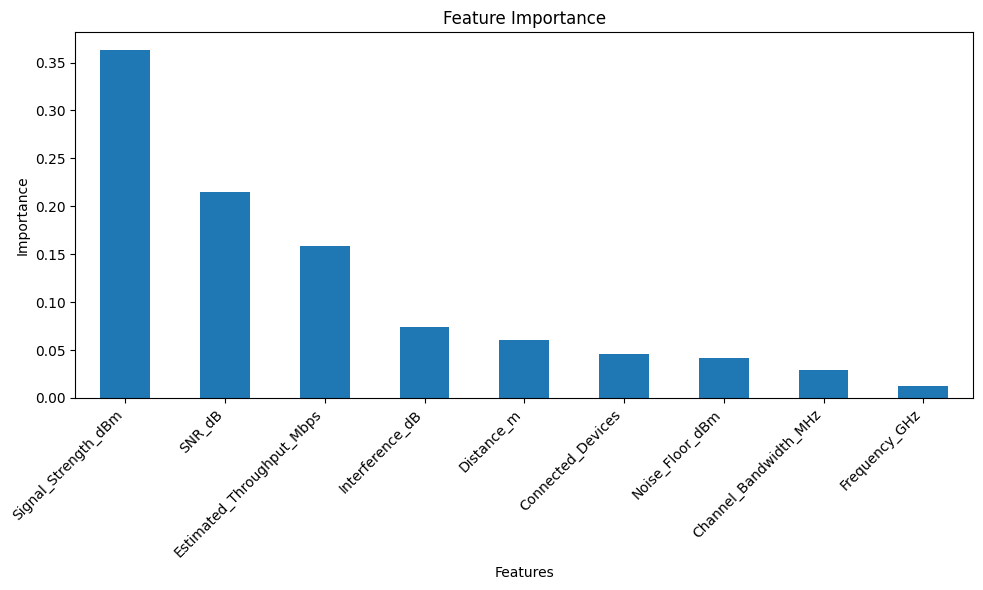

In [ ]:
plt.figure(figsize=(10,6))
importance.plot(kind='bar')
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()